In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

HQ = Path("/hpcstor6/scratch01/a/a.kanamarlapudi001/HQ_Data")
ROOTS = {
    "original": HQ / "original_study_level",
    "256": HQ / "256_study_level",
    "512": HQ / "512_study_level",
    "1024": HQ / "1024_study_level",
}
N_STUDIES = 10

In [2]:
# pick 10 studies that exist in all 4 roots
orig_studies = sorted(p.name for p in (ROOTS["original"] / "images").iterdir() if p.is_dir())
studies = []
for sid in orig_studies:
    if all((ROOTS[k] / "images" / sid).is_dir() for k in ROOTS):
        studies.append(sid)
    if len(studies) >= N_STUDIES:
        break

print(f"studies to show: {len(studies)}")
for s in studies:
    print(s)

studies to show: 10
2.25.100019467787541382690455566629544103893
2.25.100367374273455966542732604560799748101
2.25.10045169369314296912882598083529803797
2.25.100645957239980987003088505012821066303
2.25.100728502639980456404134224979379881902
2.25.10076183469920171345093105125991727647
2.25.100792847055130233617192140165927153974
2.25.100853344058030932893098873192957223449
2.25.100878324787737882095065651395442674712
2.25.100895380831890608577044236547300300363


In [3]:
def load_study_views(root: Path, study_id: str):
    img_dir = root / "images" / study_id
    files = sorted(img_dir.glob("*.npz"))
    imgs = [np.load(f)["data"] for f in files]
    return files, imgs


def show_study(study_id: str):
    fig, axes = plt.subplots(len(ROOTS), 4, figsize=(14, 3.2 * len(ROOTS)))
    for r, (label, root) in enumerate(ROOTS.items()):
        files, imgs = load_study_views(root, study_id)
        meta_dir = root / "metadata" / study_id
        for c in range(4):
            ax = axes[r, c]
            if c >= len(imgs):
                ax.axis("off")
                continue
            ax.imshow(imgs[c], cmap="gray")
            meta = {}
            jp = meta_dir / (files[c].stem + ".json")
            if jp.is_file():
                meta = json.loads(jp.read_text())
            title = f"{label} {imgs[c].shape}\n{meta.get('View', '')}"
            ax.set_title(title, fontsize=8)
            ax.axis("off")
    plt.suptitle(study_id, fontsize=10)
    plt.tight_layout()
    plt.show()

In [4]:
# assert shape + dtype for the 10 studies
EXPECTED = {
    "original": None,   # any HxW
    "256": (256, 256),
    "512": (512, 512),
    "1024": (1024, 1024),
}

ok = 0
bad = []
for sid in studies:
    for label, root in ROOTS.items():
        files, imgs = load_study_views(root, sid)
        exp = EXPECTED[label]
        for f, img in zip(files, imgs):
            if img.dtype != np.uint16:
                bad.append((sid, label, f.name, f"dtype={img.dtype}"))
            elif exp is not None and img.shape != exp:
                bad.append((sid, label, f.name, f"shape={img.shape}"))
            else:
                ok += 1

print(f"ok={ok}  bad={len(bad)}")
for b in bad[:20]:
    print("BAD", b)
assert not bad, f"{len(bad)} failures"
print("All checked images: uint16 + expected shapes.")



ok=160  bad=0
All checked images: uint16 + expected shapes.


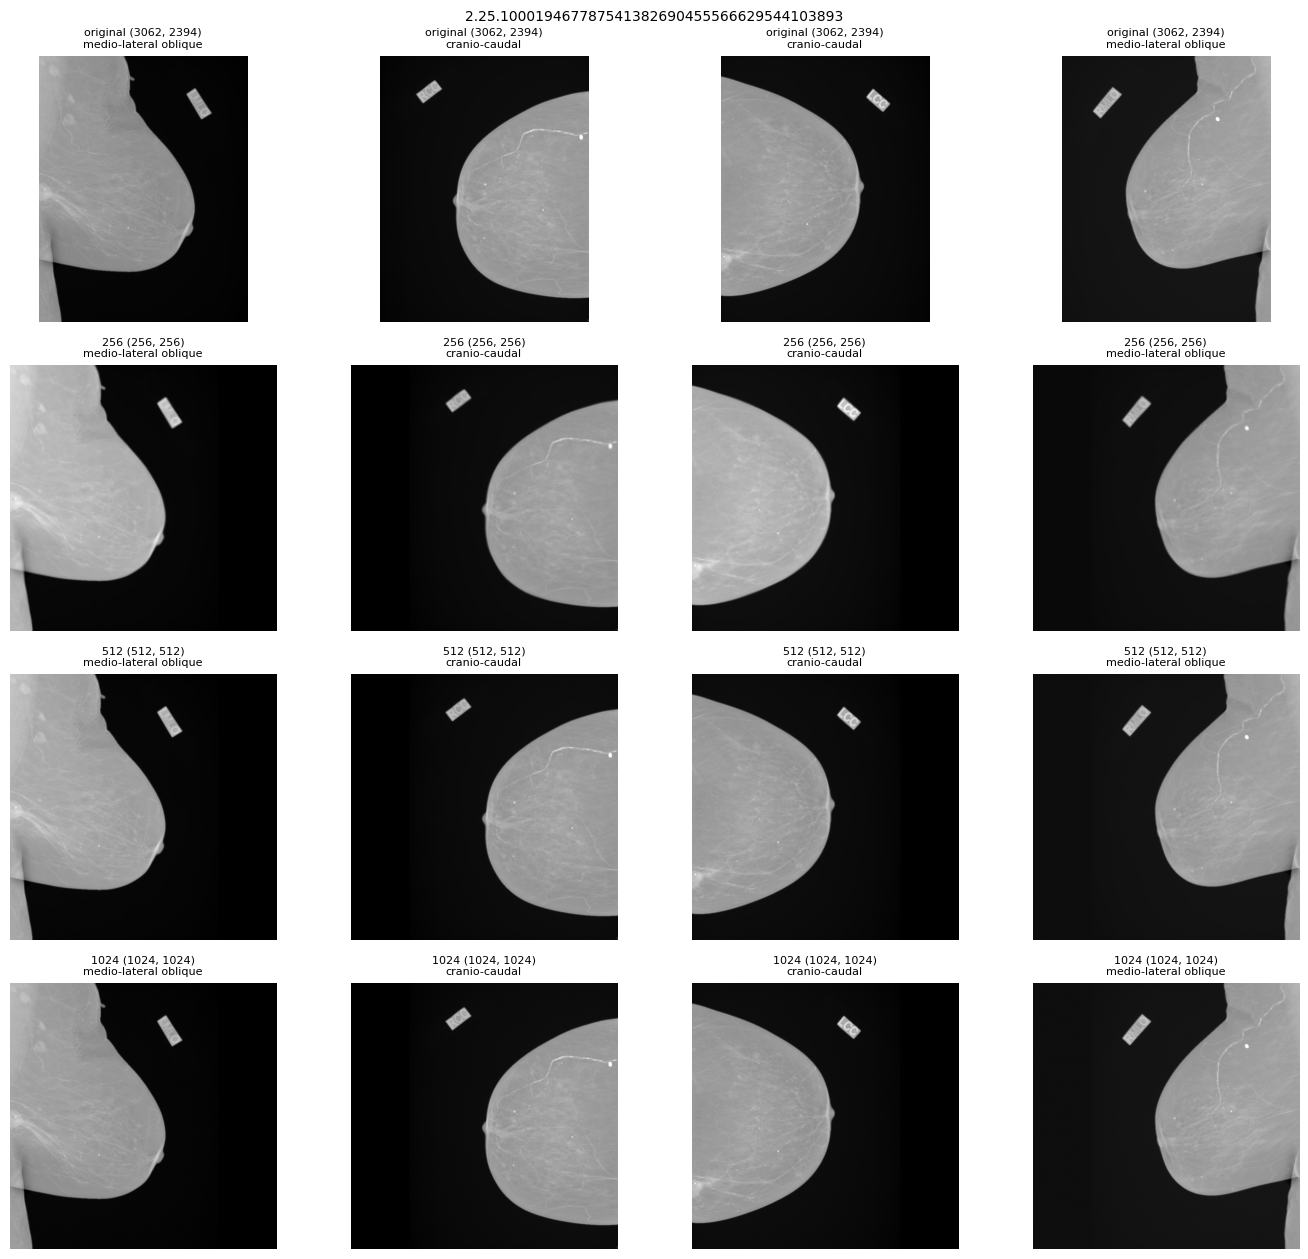

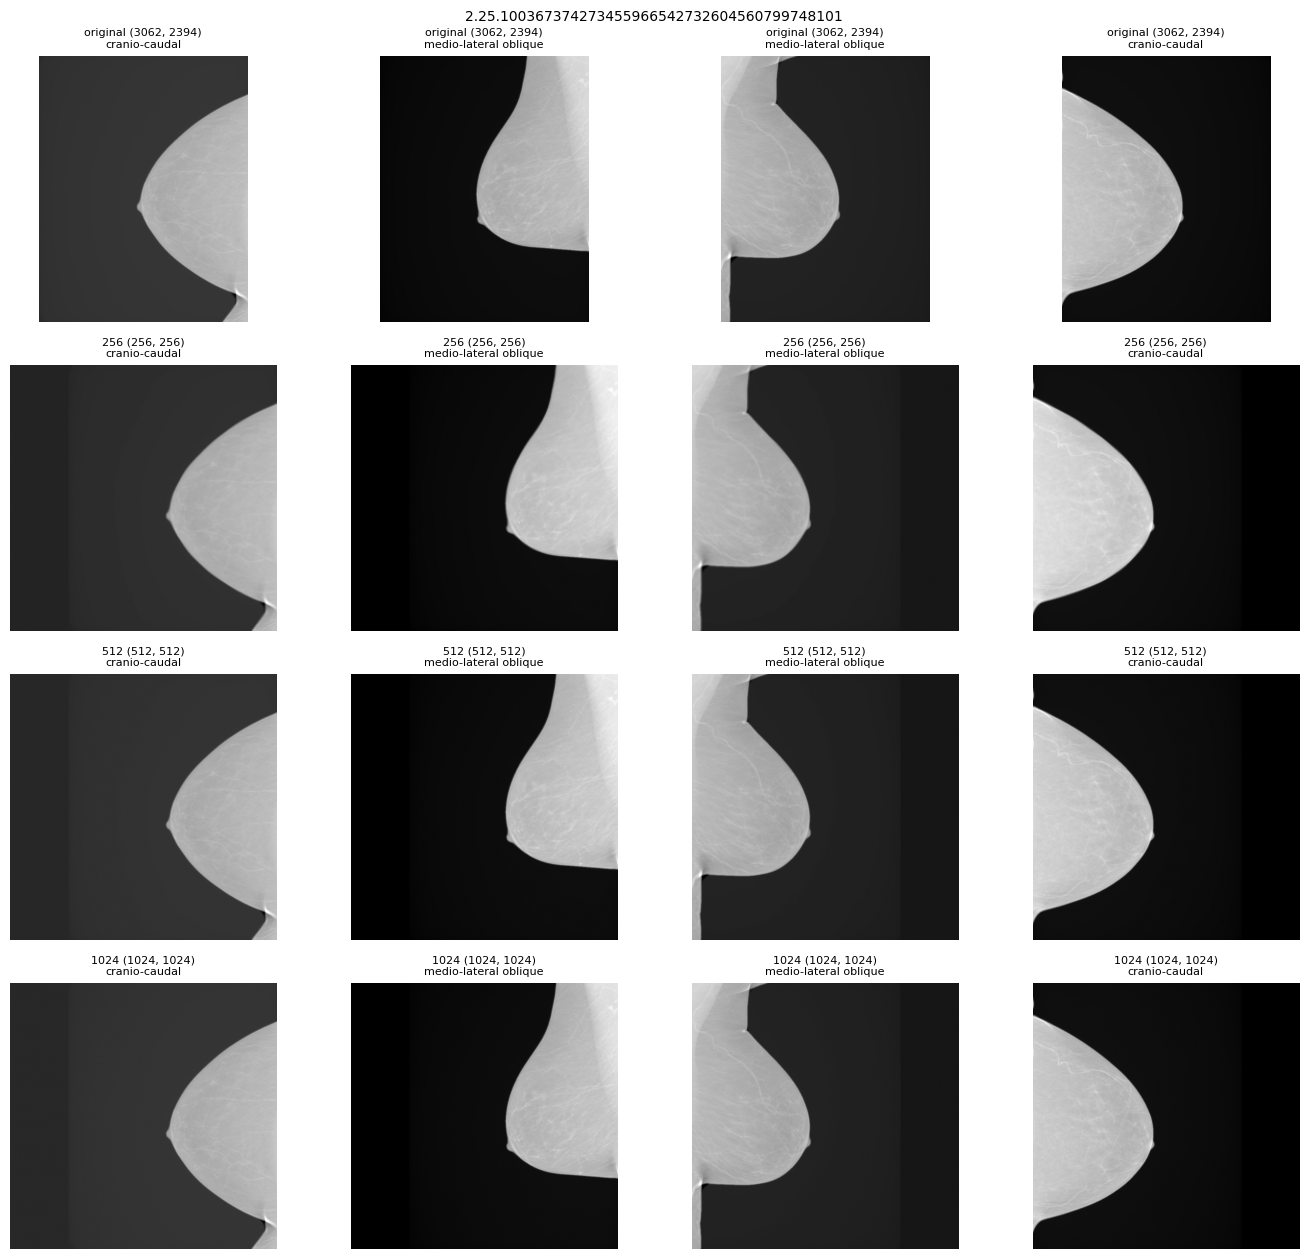

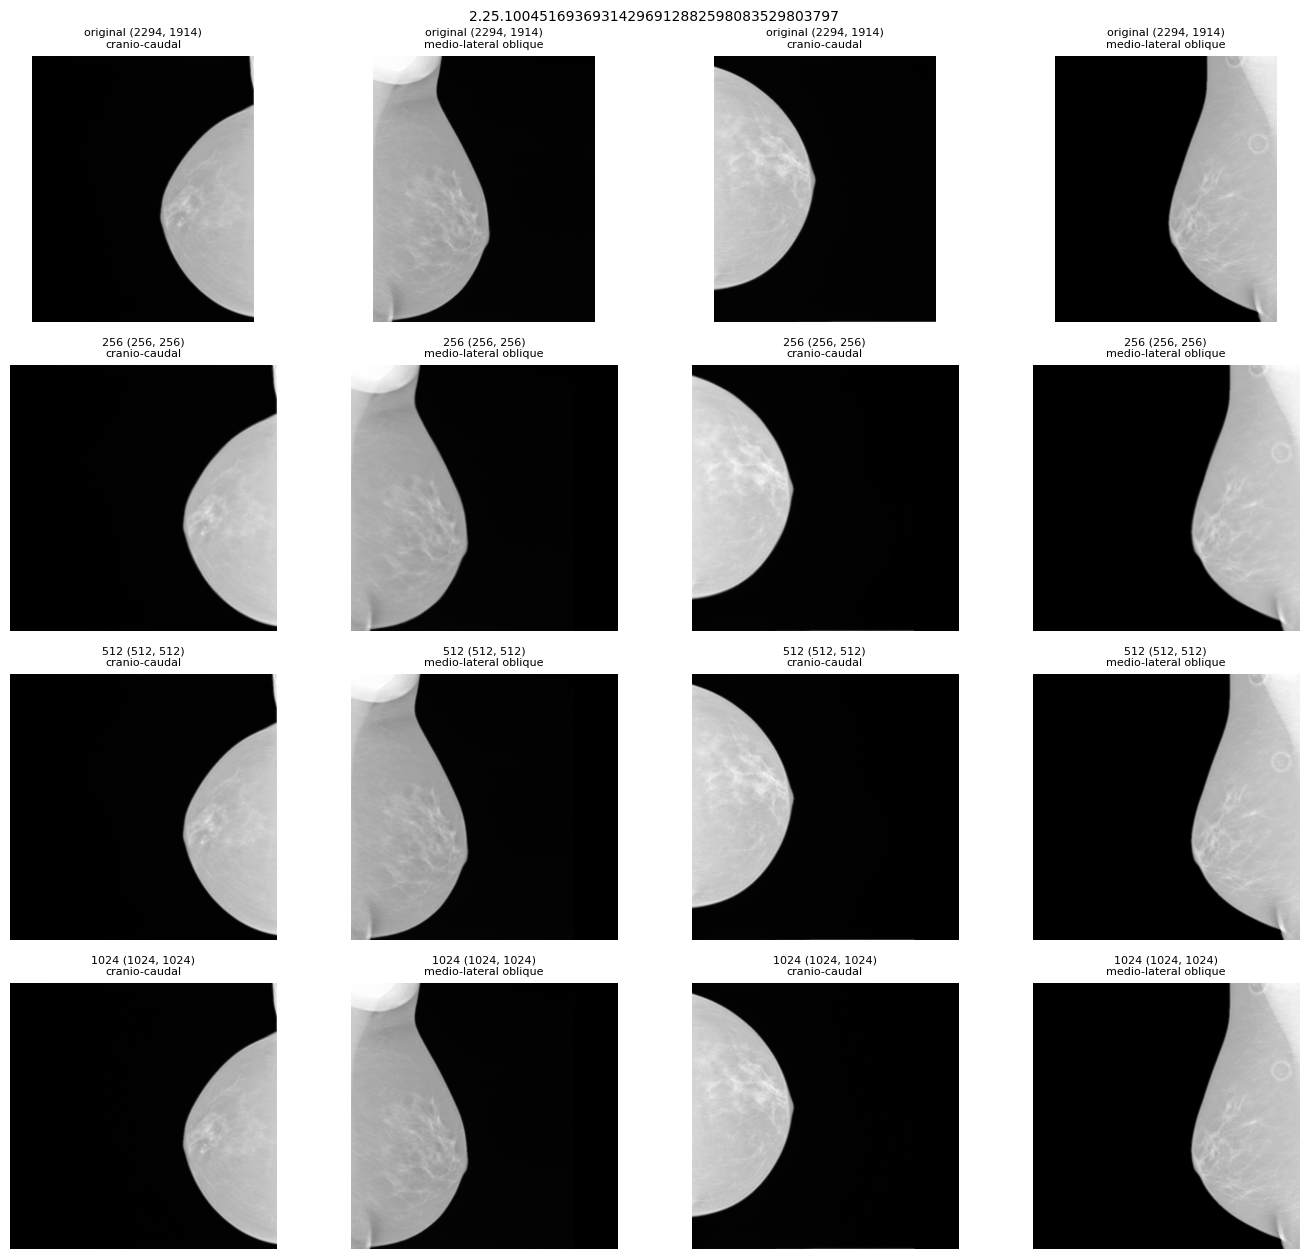

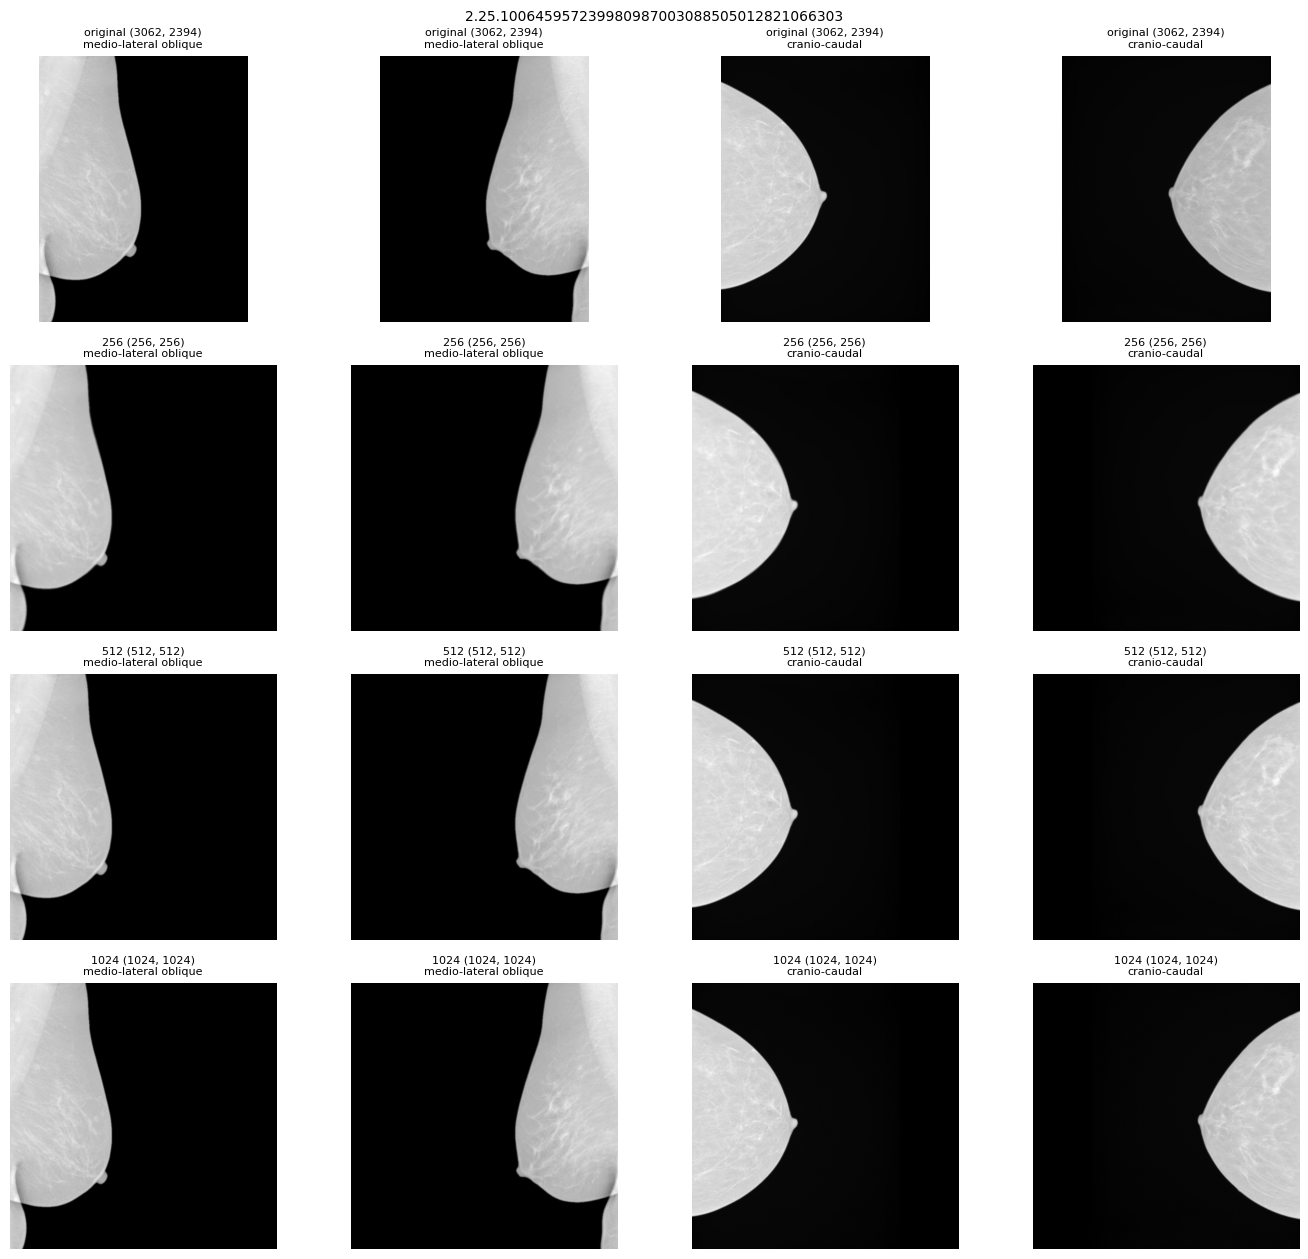

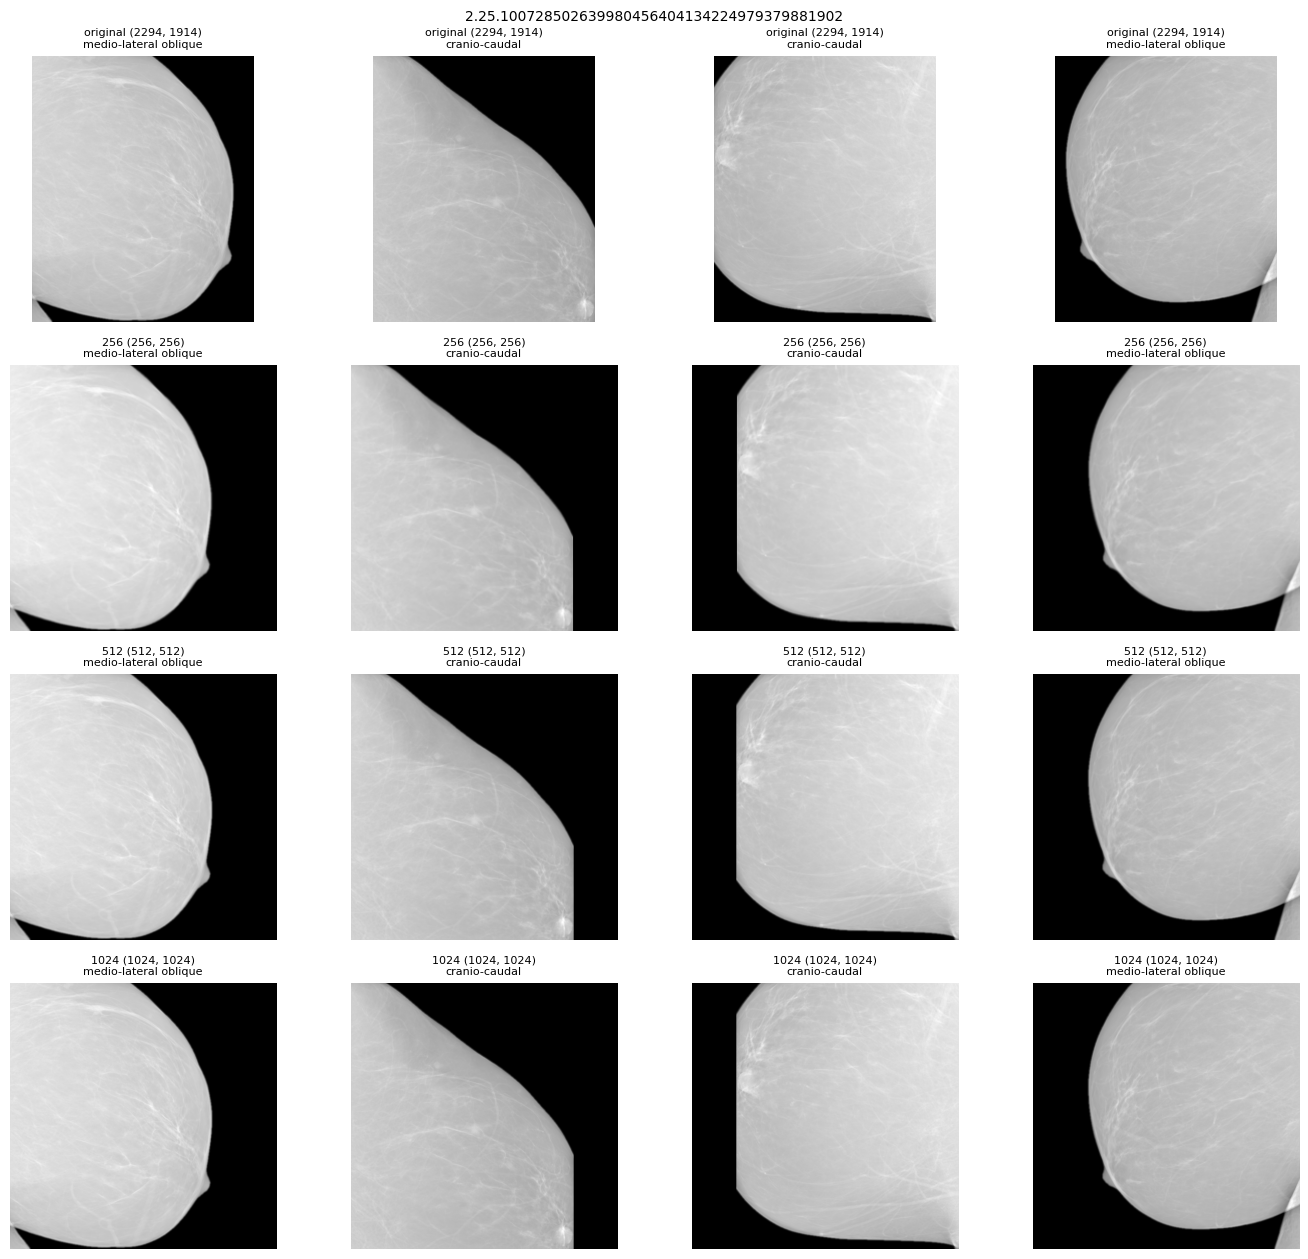

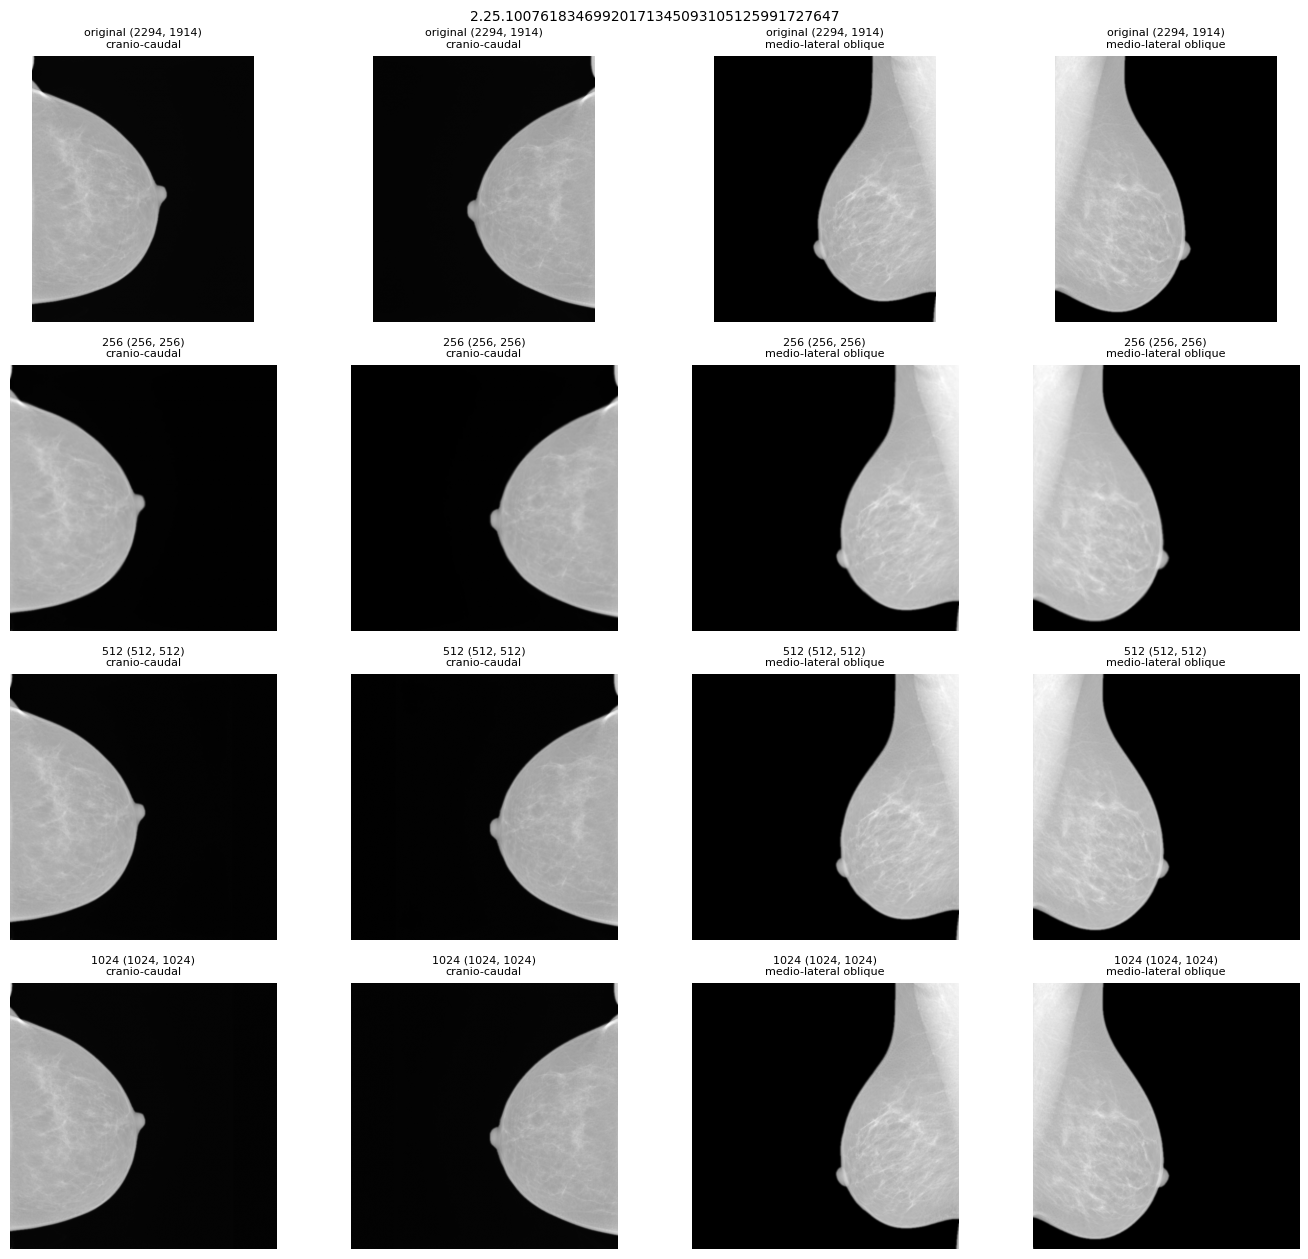

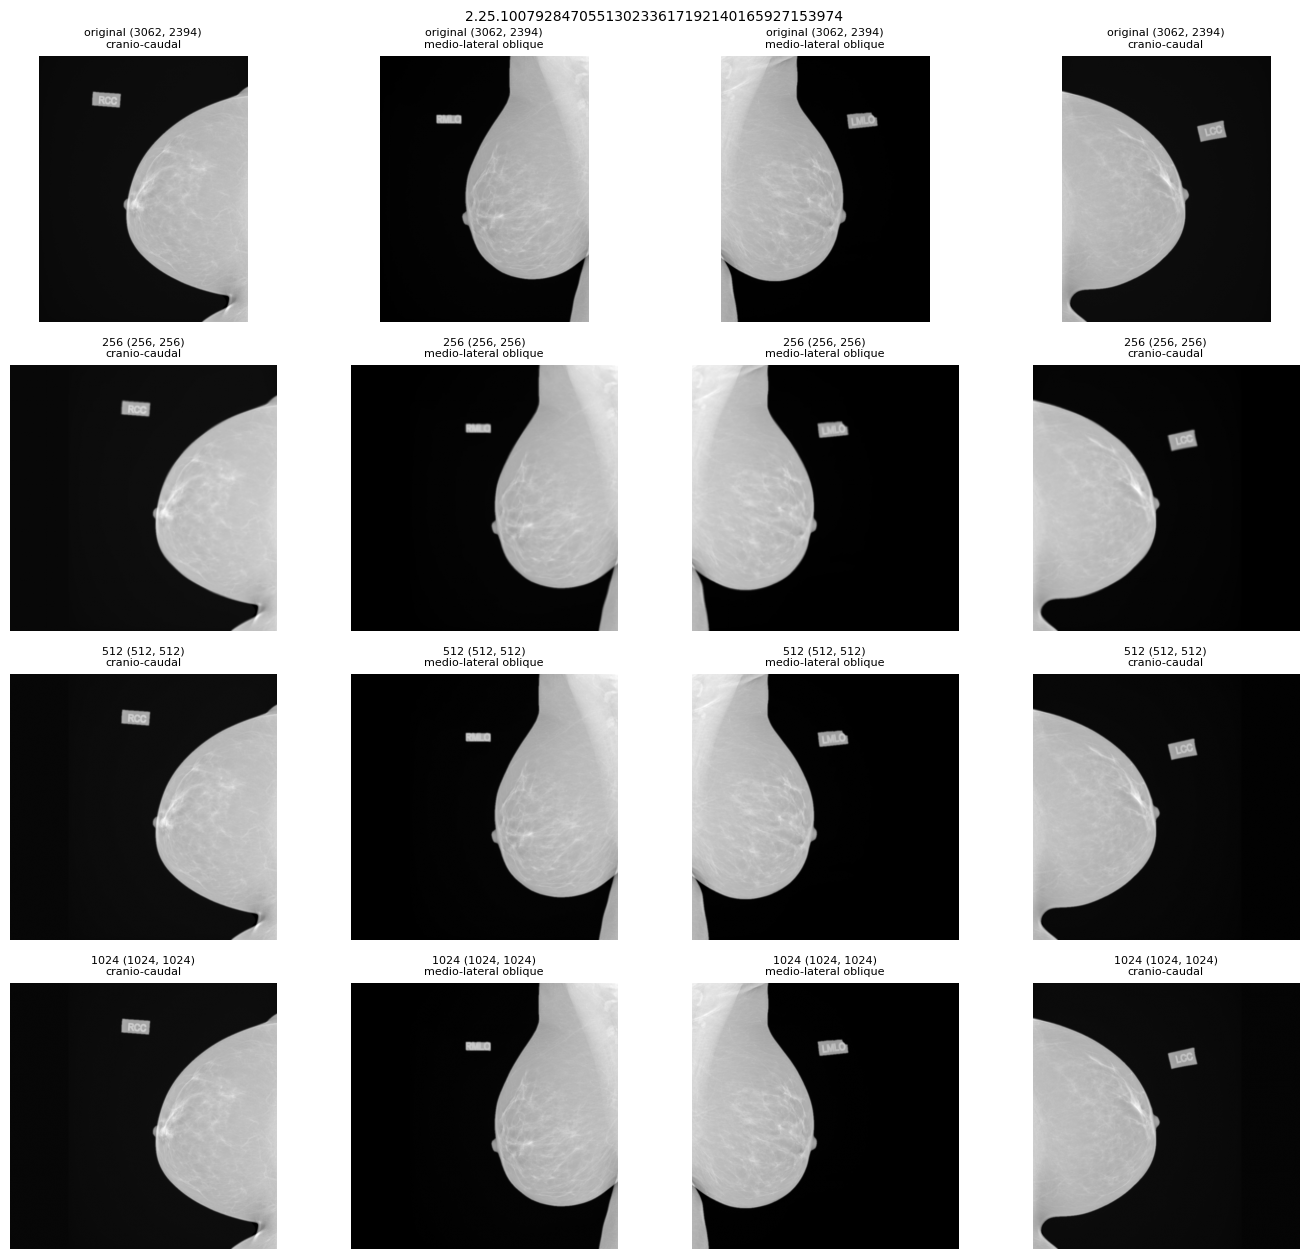

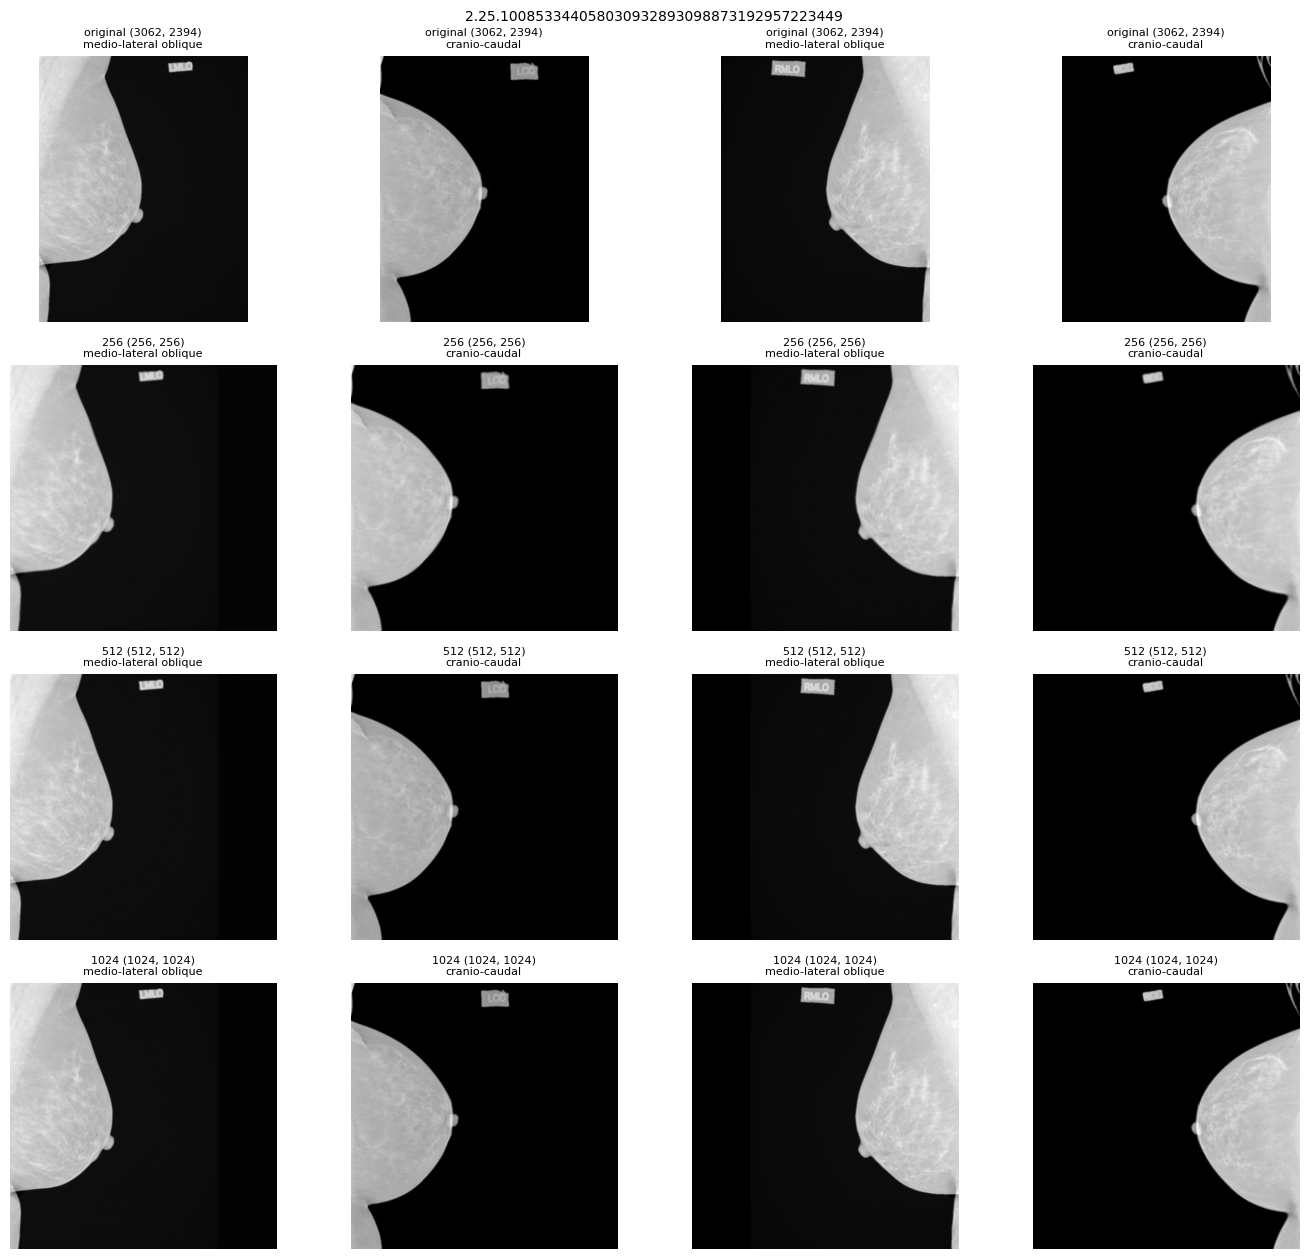

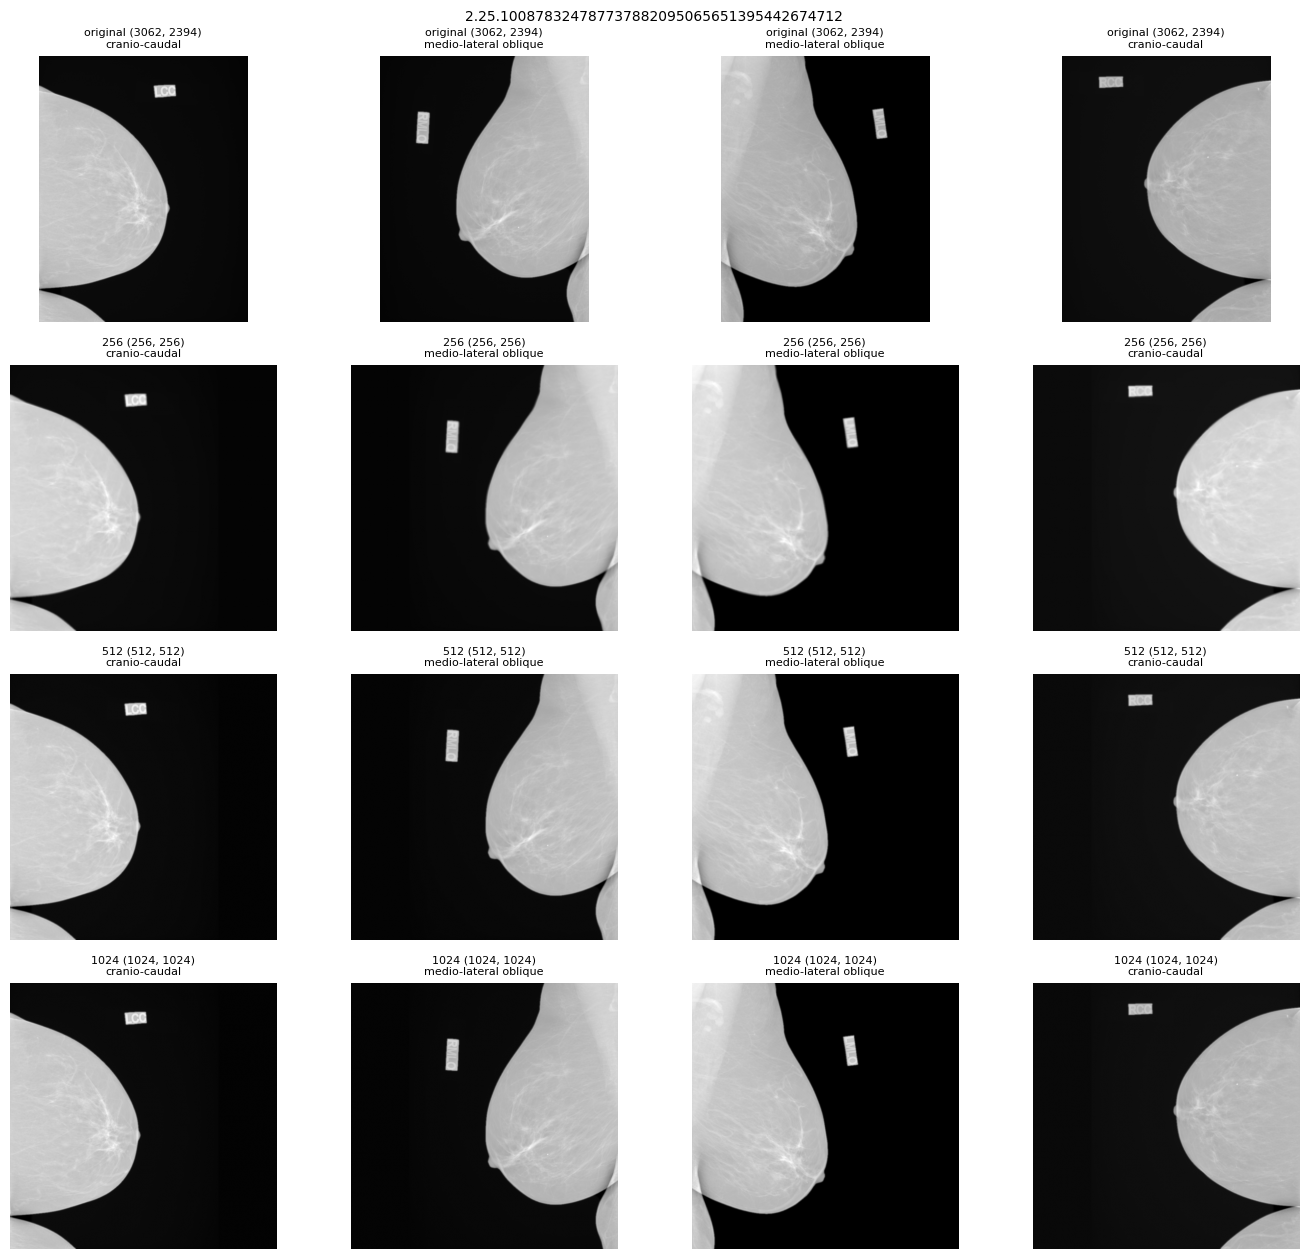

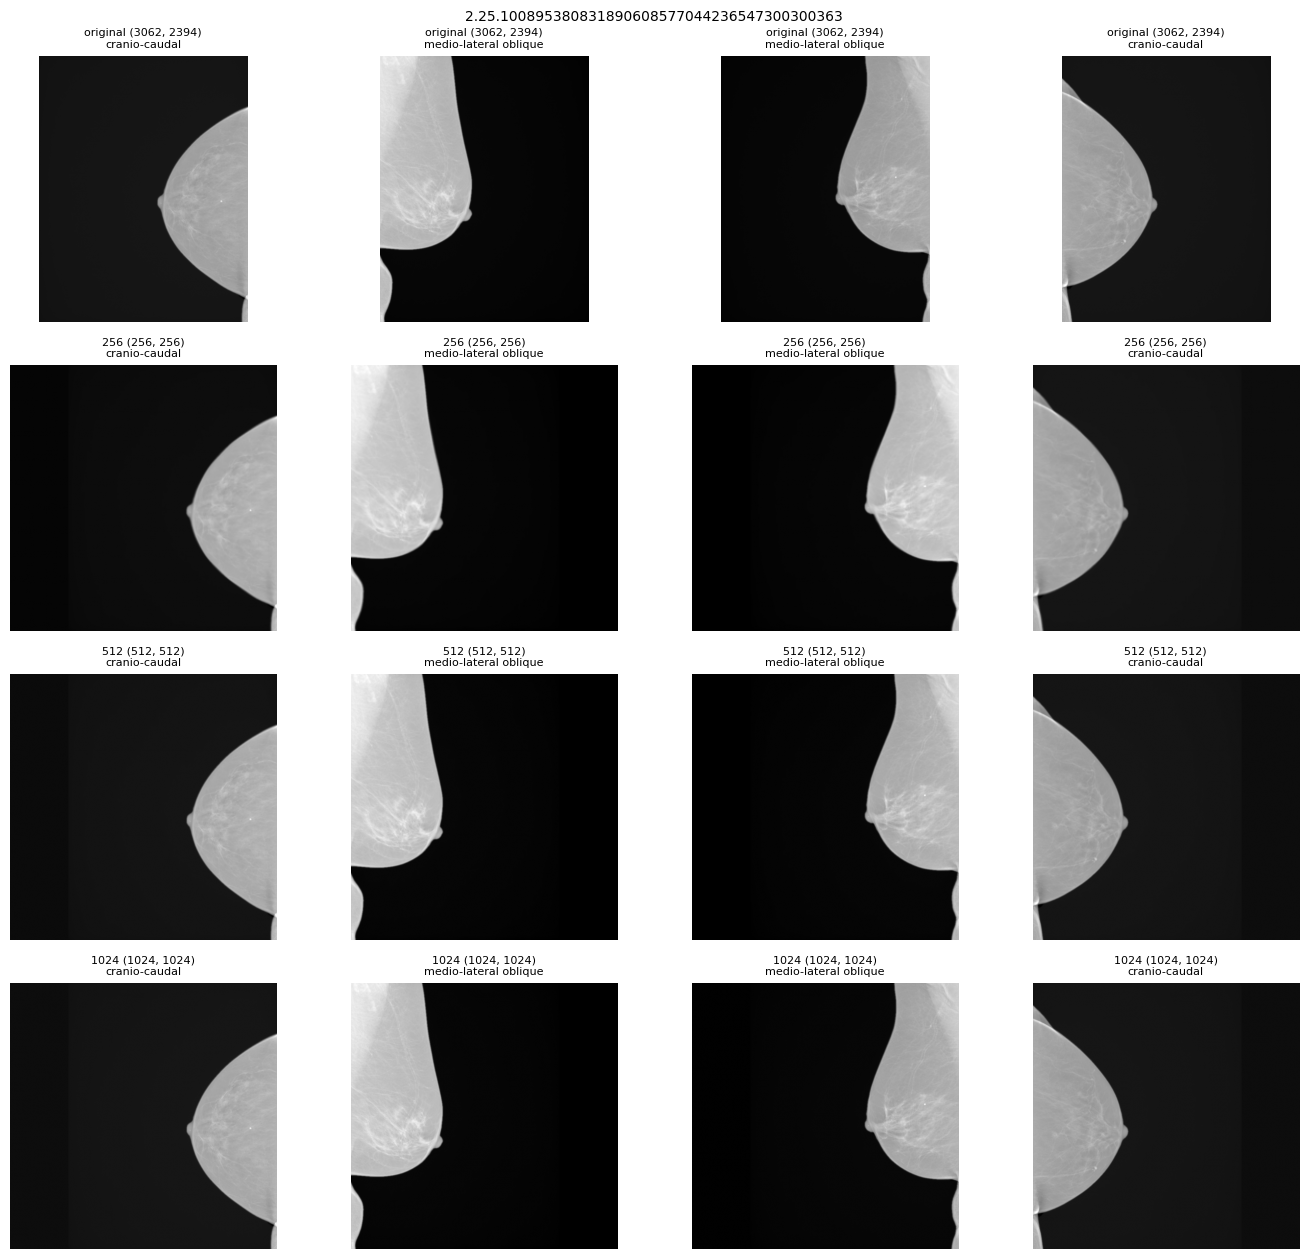

In [5]:
for sid in studies:
    show_study(sid)

In [6]:
# quick count check
for label, root in ROOTS.items():
    n_img = len(list((root / "images").glob("*/*.npz")))
    n_meta = len(list((root / "metadata").glob("*/*.json")))
    n_studies = sum(1 for p in (root / "images").iterdir() if p.is_dir())
    print(f"{label:10s}  studies={n_studies:,}  npz={n_img:,}  json={n_meta:,}")

original    studies=4,294  npz=17,176  json=17,176
256         studies=4,294  npz=17,176  json=17,176
512         studies=4,294  npz=17,176  json=17,176
1024        studies=4,294  npz=17,176  json=17,176
